# Compare feature selection thresholds

In [38]:
import os
from pathlib import Path

import pickle
import numpy as np
from tqdm.notebook import tqdm
import json
import matplotlib.pyplot as plt

from methyldl.deconvolution.feature_selection import (
    apply_feature_mask,
    apply_mask_to_ios,
    compute_feature_mask,
    compute_feature_ratios,
    extract_pure_feature_matrix,
)
from methyldl.deconvolution.evaluation import compute_deconvolution_metrics
from methyldl.deconvolution.least_squares_deconvolvers import PSLSDeconvolver, NNLSDeconvolver

In [39]:
with open("../App/labels_dict.json", "r") as f:
    labels_dict = json.load(f)

In [40]:
labels_dict

{'0': 'Adipocytes',
 '1': 'Bladder-Ep',
 '2': 'Blood-B',
 '3': 'Blood-Granul',
 '4': 'Blood-Mono+Macro',
 '5': 'Blood-NK',
 '6': 'Blood-T',
 '7': 'Bone-Osteob',
 '8': 'Breast-Basal-Ep',
 '9': 'Breast-Luminal-Ep',
 '10': 'Colon-Ep',
 '11': 'Colon-Fibro',
 '12': 'Dermal-Fibro',
 '13': 'Endothel',
 '14': 'Epid-Kerat',
 '15': 'Eryth-prog',
 '16': 'Fallopian-Ep',
 '17': 'Gallbladder',
 '18': 'Gastric-Ep',
 '19': 'Head-Neck-Ep',
 '20': 'Heart-Cardio',
 '21': 'Heart-Fibro',
 '22': 'Kidney-Ep',
 '23': 'Liver-Hep',
 '24': 'Lung-Ep-Alveo',
 '25': 'Lung-Ep-Bron',
 '26': 'Neuron',
 '27': 'Oligodend',
 '28': 'Ovary-Ep',
 '29': 'Pancreas-Acinar',
 '30': 'Pancreas-Alpha',
 '31': 'Pancreas-Beta',
 '32': 'Pancreas-Delta',
 '33': 'Pancreas-Duct',
 '34': 'Prostate-Ep',
 '35': 'Skeletal-Musc',
 '36': 'Small-Int-Ep',
 '37': 'Smooth-Musc',
 '38': 'Thyroid-Ep'}

In [22]:
rng = np.random.default_rng()

In [ ]:
rng.choice()

In [2]:
MATRICES_PATH = Path("../Data/extended_proportions/pseudobulk/dismir_soft_labels_with_pooling/ios_full_matrices.npz")
dismir_sl_matrices = np.load(MATRICES_PATH)
dismir_sl_pure_profiles = pickle.load(open("../Data/extended_proportions/pseudobulk/dismir_soft_labels_with_pooling/pure_profiles.pkl", "rb"))
dismir_sl_test_data = dismir_sl_matrices["features_test_uniform_multinomial"]

In [23]:
random_indices = rng.choice(dismir_sl_test_data.shape[0], size=20000, replace=False)
dismir_sl_test_data_subsampled = dismir_sl_test_data[random_indices]

In [3]:
pure_train = extract_pure_feature_matrix(
    dismir_sl_pure_profiles, 39, 39, split_idx=0, splits=["train", "valid", "test"]
)
# obtain validation set feature ratios for the pure profiles
pure_valid = extract_pure_feature_matrix(
    dismir_sl_pure_profiles, 39, 39, split_idx=1, splits=["train", "valid", "test"]
)
valid_ratios = compute_feature_ratios(pure_valid)

In [ ]:
test_preds = {}

In [34]:
# n_features_list = np.arange(39, 39 * (4+1), 39)
n_features_list = [40, 41, 42, 43, 44]
labels = np.arange(39)
for n_features in n_features_list:
    mask, cutoff = compute_feature_mask(
        valid_ratios,
        cutoff=None,
        guarantee_diagonal_selection=True,
        guarantee_columns_selection=None,
        top_features=n_features,
        return_cutoff=True
    )

    feature_data = apply_feature_mask(dismir_sl_test_data_subsampled, mask)
    reference_features = apply_feature_mask(pure_train, mask)
    nnls_deconvolver = NNLSDeconvolver()
    _ = nnls_deconvolver.fit(reference_features, labels)
    pred_test = nnls_deconvolver.predict(feature_data.reshape(feature_data.shape[0], -1))[0]
    test_preds[n_features] = pred_test

Predicting with NNLS sequentially: 100%|██████████| 20000/20000 [00:13<00:00, 1440.38it/s]


In [35]:
# compute deconvolution metrics
deconv_metrics = {}
for n_features, pred in test_preds.items():
    metrics = compute_deconvolution_metrics(
        pred=pred,
        target=dismir_sl_matrices["proportions_test"][random_indices],
        compute_ci=False
    )
    deconv_metrics[n_features] = metrics

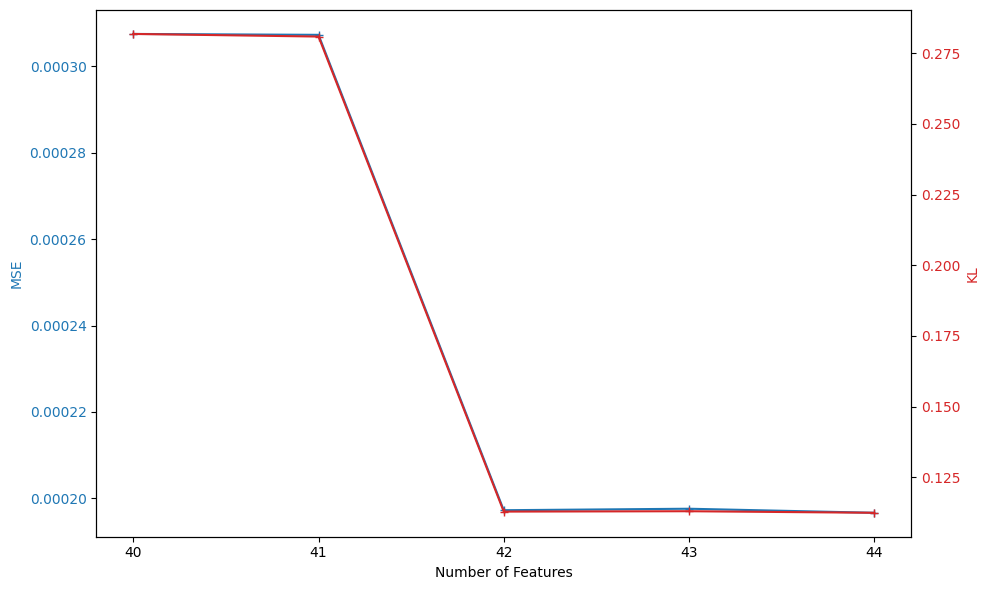

In [36]:
# plot MSE and KL
fig, ax1 = plt.subplots(figsize=(10, 6))

# MSE
ax1.set_xlabel("Number of Features")
ax1.set_xticks(n_features_list)
ax1.set_ylabel("MSE", color="tab:blue")
ax1.plot(n_features_list, [deconv_metrics[n]["mse"] for n in n_features_list], color="tab:blue", marker="+")
ax1.tick_params(axis="y", labelcolor="tab:blue")

# KL
ax2 = ax1.twinx()
ax2.set_ylabel("KL", color="tab:red")
ax2.plot(n_features_list, [deconv_metrics[n]["kl"] for n in n_features_list], color="tab:red", marker="+")
ax2.tick_params(axis="y", labelcolor="tab:red")

fig.tight_layout()
plt.show()


In [37]:
mask, cutoff = compute_feature_mask(
        valid_ratios,
        cutoff=None,
        guarantee_diagonal_selection=True,
        guarantee_columns_selection=None,
        top_features=42,
        return_cutoff=True
    )

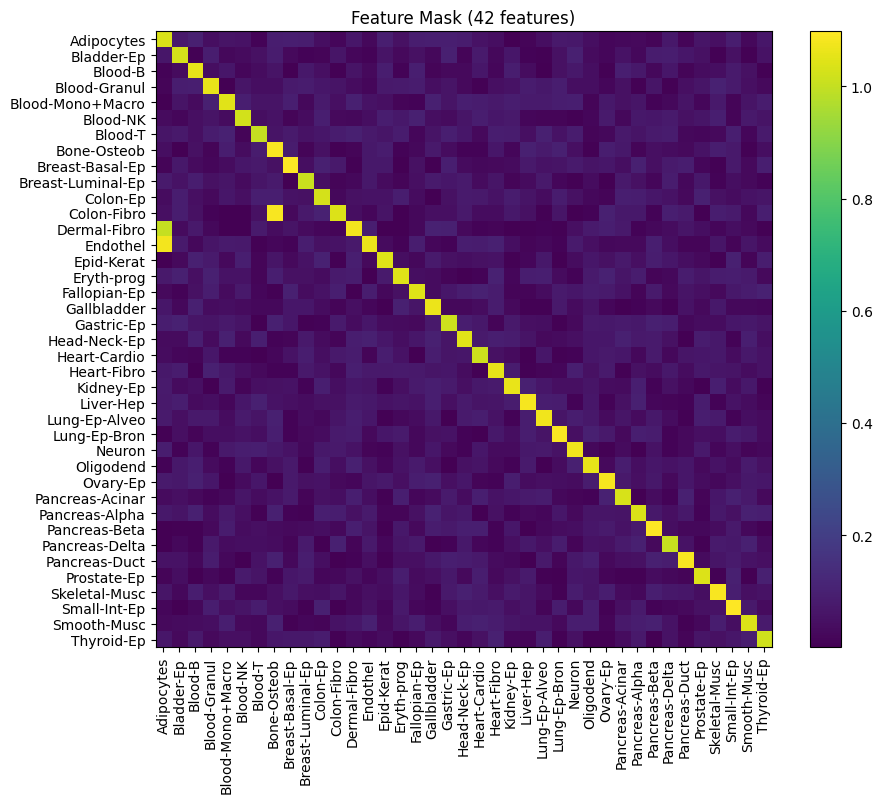

In [46]:
plt.figure(figsize=(10, 8))
plt.imshow(mask+np.random.rand(*mask.shape)*0.1)  # add some noise for better visualization
plt.colorbar()
plt.title("Feature Mask (42 features)")
plt.xticks(ticks=np.arange(39), labels=[labels_dict[str(i)] for i in range(39)], rotation=90)
plt.yticks(ticks=np.arange(39), labels=[labels_dict[str(i)] for i in range(39)])
plt.show()